In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = 'https://github.com/KSTSV/diploma/raw/main/%D0%B8%D1%82%D0%BE%D0%B3%D0%BE%D0%B2%D1%8B%D0%B9%20%D0%BC%D0%B0%D1%81%D1%81%D0%B8%D0%B2%20%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.xlsx'
data = pd.read_excel(url).drop(['ID', 'town'], axis=1)
data = data.replace(99999999, np.nan)

In [ ]:
cat_cols = ['gndr', 'marital_stat', 'initiative1_employer',
       'initiative2_persona', 'money_what_employer', 'money_what_persona',
       'money_what_free_other', 'is_spec_crs', 'profwrk']

ord_cols = ['edu', 'change_sal',
       'title_wrk', 'incm']

cat_ord = ['gndr', 'marital_stat', 'initiative1_employer',
       'initiative2_persona', 'money_what_employer', 'money_what_persona',
       'money_what_free_other', 'is_spec_crs', 'profwrk', 'edu', 'change_sal',
       'title_wrk', 'incm']

int_ord = ['agea', 'agewrk', 'fctr_succ1', 'fctr_succ2', 'fctr_succ3',
       'fctr_succ4', 'impmot1', 'impmot2', 'impmot3', 'impmot4', 'impmot5',
       'impmot6', 'impmot7', 'impmot8', 'impmot9', 'mot1', 'mot10', 'mot11',
       'mot12', 'mot13', 'mot14', 'mot2', 'mot3', 'mot4', 'mot5', 'mot6',
       'mot7', 'mot8', 'mot9', 'num_crs', 'plcwrk', 'sal', 'sat_wrk', 'edu', 'change_sal',
       'title_wrk', 'incm']

int_cols = data.drop(cat_cols, axis=1).drop(ord_cols, axis=1).columns


miss_vars= ["marital_stat", "num_crs",
            "mot1", "mot2", "mot3", "mot4", "mot5", "mot6", "mot7", "mot8", "mot9", "mot10", "mot11", "mot12", "mot13", "mot14",
            "edu", "agewrk", "plcwrk", "profwrk", "change_sal", "title_wrk", "sal", "sat_wrk",
            "fctr_succ1", "fctr_succ2", "fctr_succ3", "fctr_succ4",
            "impmot1", "impmot2", "impmot3", "impmot4", "impmot5", "impmot6", "impmot7", "impmot8", "impmot9",
            "agea", "incm"]

mcar = ["marital_stat", "num_crs",
        "mot2", "mot6",  "mot9", "mot10", "mot11", "mot12", "mot13",
        "agewrk", "plcwrk", "sat_wrk",
        "fctr_succ3", "fctr_succ4",
        "impmot1", "impmot4", "impmot5", "impmot8", "agea", "incm", "title_wrk"]

mar = ["mot1", "mot3", "mot4", "mot5", "mot7", "mot8", "mot14",
       "edu", "profwrk", "change_sal", "sal", "fctr_succ1",
       "fctr_succ2", "impmot2", "impmot3", "impmot6", "impmot7", "impmot9"]


mcar_cat = ['marital_stat']
mcar_ord = ['incm', 'title_wrk']
mcar_int = ['mot2', 'agea', 'mot9', 'fctr_succ4',
            'mot6', 'mot10', 'mot11', 'mot12', 'mot13',
            'impmot1', 'incm', 'impmot4', 'impmot8', 'fctr_succ3', 'agewrk',
            'plcwrk', 'sat_wrk', 'impmot5', 'num_crs']



mar_int = ['impmot2', 'impmot7', 'mot1', 'mot14', 'impmot6', 'mot3', 'fctr_succ2', 'impmot3', 'mot8', 'mot4', 'mot7', 'impmot9', 'mot5', 'sal', 'fctr_succ1']
mar_cat = ['profwrk']
mar_ord = ['edu', 'change_sal']


not_mis = ['gndr', 'initiative1_employer', 'initiative2_persona', 'is_spec_crs',
       'money_what_employer', 'money_what_free_other', 'money_what_persona']

In [ ]:
import scipy
from scipy.stats import entropy

In [ ]:
entropy(data['marital_stat'].dropna())

np.float64(5.191195578937104)

In [ ]:
round(data[i].mean(),2)

np.float64(2.86)

In [ ]:
ddd = pd.DataFrame()
for i in data.columns:
  if i in int_cols:
    ddd.loc[1, i+'_mean'] = str(round(data[i].mean(), 2)) #+ ' ± ' + str(round((data[i].std() / np.sqrt(data[i].shape[0]) * 1.96), 2))
    ddd.loc[1,i+'_var'] = str(round(data[i].var(), 2)) #+ ' ± ' + str(round((data[i].std() / np.sqrt(data[i].shape[0]) * 1.96), 2))
  elif i in ord_cols:
    ddd.loc[1, i+'_mean'] = str(round(data[i].mean(), 2)) #+ ' ± ' + str(round((data[i].std() / np.sqrt(data[i].shape[0]) * 1.96), 2))
    ddd.loc[1, i+'_var'] = str(round(data[i].var(), 2))#+ ' ± ' + str(round((data[i].std() / np.sqrt(data[i].shape[0]) * 1.96), 2))
    ddd.loc[1, i+'_med'] = str(round(data[i].median(), 2))#+ ' ± ' + str(round((data[i].std() / np.sqrt(data[i].shape[0]) * 1.96), 2))
    ddd.loc[1, i+'_ent'] = str(round(entropy(data[i].dropna()), 2))#+ ' ± ' + str(round((data[i].std() / np.sqrt(data[i].dropna().shape[0]) * 1.96), 2))
  else:
    ddd.loc[1, i+'_mode'] = str(round(float(data[i].mode()), 2))#+ ' ± ' + str(round((data[i].std() / np.sqrt(data[i].shape[0]) * 1.96), 2))
    ddd.loc[1, i+'_ent'] = str(round(entropy(data[i].dropna()), 2))#+ ' ± ' + str(round((data[i].std() / np.sqrt(data[i].dropna().shape[0]) * 1.96), 2))


<ipython-input-9-192e86802040>:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ddd.loc[1, i+'_mode'] = str(round(float(data[i].mode()), 2))#+ ' ± ' + str(round((data[i].std() / np.sqrt(data[i].shape[0]) * 1.96), 2))
<ipython-input-9-192e86802040>:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ddd.loc[1, i+'_mode'] = str(round(float(data[i].mode()), 2))#+ ' ± ' + str(round((data[i].std() / np.sqrt(data[i].shape[0]) * 1.96), 2))
<ipython-input-9-192e86802040>:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ddd.loc[1, i+'_mode'] = str(round(float(data[i].mode()), 2))#+ ' ± ' + str(round((data[i].std() / np.sqrt(data[i].shape[0]) * 1.96), 2))
<ipython-input-9-192e86802040>:12: FutureWarning:

In [ ]:
ddd

,gndr_mode,gndr_ent,marital_stat_mode,marital_stat_ent,num_crs_mean,num_crs_var,initiative1_employer_mode,initiative1_employer_ent,initiative2_persona_mode,initiative2_persona_ent,...,impmot8_mean,impmot8_var,impmot9_mean,impmot9_var,agea_mean,agea_var,incm_mean,incm_var,incm_med,incm_ent
1,1.0,5.48,1.0,5.19,5.24,9.14,0.0,4.39,1.0,5.52,...,2.33,2.97,3.61,5.36,36.74,93.95,2.86,0.39,3.0,5.47


In [ ]:
ddd.T.to_excel('var_real.xlsx')

In [ ]:
sl = pd.read_excel('/content/расшифровка переменных.xlsx')
sl = sl.set_index('name').to_dict()['Unnamed: 2']

In [ ]:
sl['num_crs'] = 'Количество пройденных курсов'

In [ ]:
d = data.rename(columns = sl)

In [ ]:
data[int_cols].describe().to_excel('opis_stata_ord.xlsx')

In [ ]:
ss = {}

for i in int_cols:
  ss[i] = sl[i]

In [ ]:
d

,Пол,Семейное положение,Количество пройденных курсов,Инициатива пойти на курсы (работодатель),Инициатива пойти на курсы (самостоятельное решение),Оплата курсов (работодатель),Оплата курсов (из личных средств),Оплата курсов (бесплатно/другие источники),Соспадение специальности курса с профилем работы,Суждение о мотивации 1,...,Суждение о мотивах 2,Суждение о мотивах 3,Суждение о мотивах 4,Суждение о мотивах 5,Суждение о мотивах 6,Суждение о мотивах 7,Суждение о мотивах 8,Суждение о мотивах 9,Возраст,Уровень дохода
0,1,1.0,7.0,0,1,1,1,1,1,7.0,...,7.0,7.0,7.0,7.0,4.0,4.0,6.0,6.0,27.0,3.0
1,2,1.0,4.0,0,1,1,1,1,2,7.0,...,3.0,NaN,5.0,4.0,5.0,5.0,1.0,5.0,38.0,3.0
2,2,7.0,8.0,1,1,1,1,1,1,3.0,...,4.0,6.0,1.0,5.0,3.0,5.0,NaN,5.0,26.0,4.0
3,1,2.0,9.0,0,1,0,1,0,2,6.0,...,3.0,6.0,6.0,6.0,5.0,6.0,1.0,4.0,47.0,3.0
4,1,7.0,2.0,1,1,1,0,0,2,6.0,...,5.0,7.0,5.0,6.0,7.0,7.0,5.0,7.0,21.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,2,1.0,3.0,0,1,0,1,0,2,6.0,...,1.0,1.0,1.0,1.0,7.0,4.0,1.0,1.0,33.0,3.0
251,1,1.0,10.0,1,1,1,1,1,1,7.0,...,4.0,5.0,6.0,4.0,4.0,4.0,1.0,2.0,40.0,3.0
252,2,7.0,NaN,0,1,1,0,1,2,6.0,...,5.0,7.0,1.0,7.0,6.0,4.0,4.0,4.0,25.0,3.0
253,2,1.0,NaN,0,1,1,0,0,2,7.0,...,1.0,7.0,1.0,7.0,6.0,7.0,1.0,7.0,47.0,3.0


In [ ]:
d['edu'].unique()

array([ 7.,  6.,  5.,  3.,  8., nan,  2.])

# График пропуски

In [ ]:
data.isna().sum() [ data.isna().sum() > 0]

,0
marital_stat,7
num_crs,11
mot1,7
mot2,8
mot3,8
mot4,8
mot5,10
mot6,9
mot7,10
mot8,12


<Axes: >

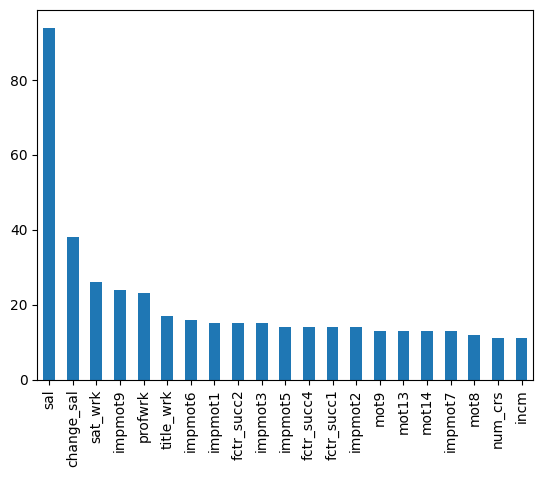

In [ ]:
data.isna().sum() [ data.isna().sum() > 10].sort_values(ascending = False).plot(kind= 'bar')

# ГРАФИК ВОЗРАСТ

<Axes: >

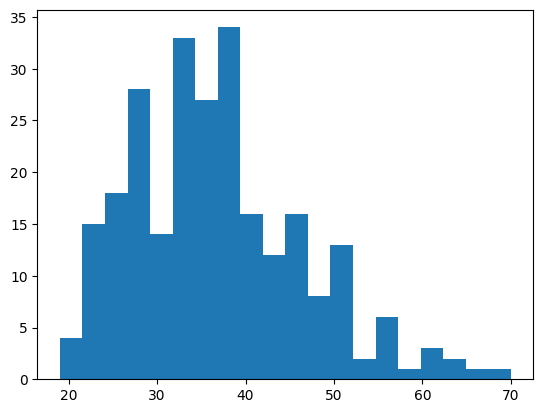

In [ ]:
data['agea'].hist(bins = 20, grid=False, )

# График зп

<Axes: >

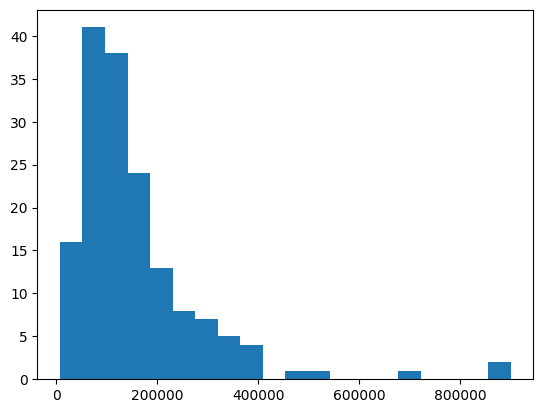

In [ ]:
data['sal'].hist(bins = 20, grid=False, )

# график  agewrk, plcwrk



<Axes: >

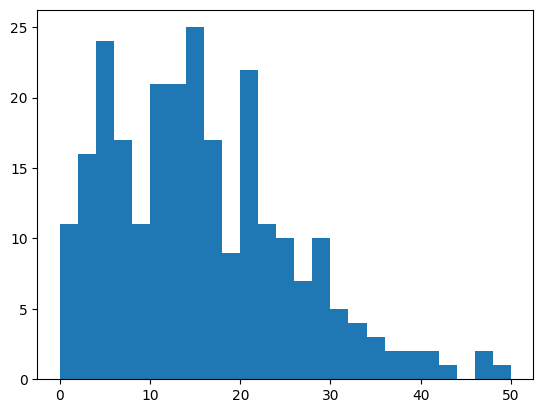

In [ ]:
data['agewrk'].hist(bins = 25, grid=False, )

<Axes: >

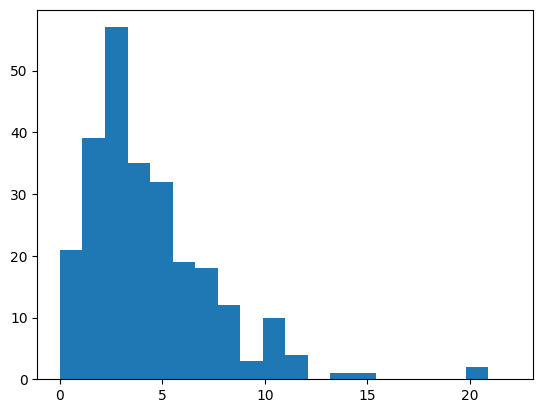

In [ ]:
data['plcwrk'].hist(bins = 20, grid=False, range=[0, 22])

In [ ]:
sum(data['plcwrk']<=5)/255

0.7215686274509804

In [ ]:
sum(data['agewrk']<=30) / 255

0.9254901960784314

# График num_crs

<Axes: >

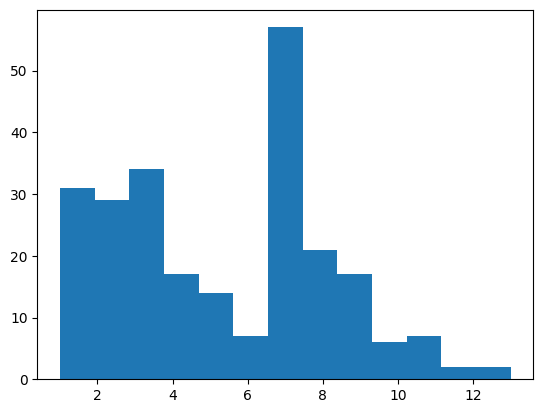

In [ ]:
data['num_crs'].hist(bins = 13, grid=False)

In [ ]:
sum(data['num_crs']<=2) / 255

0.23529411764705882

<Axes: >

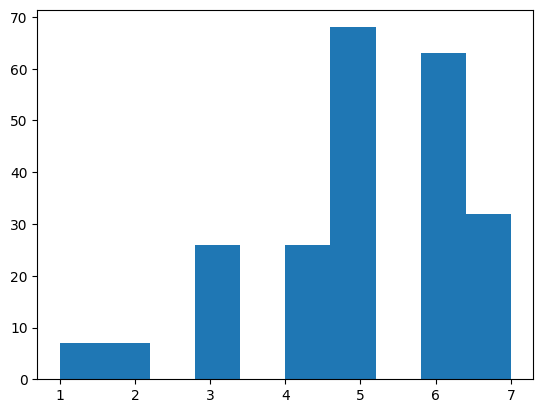

In [ ]:
data['sat_wrk'].hist(grid=False)

In [ ]:
d.columns

Index(['Пол', 'Семейное положение', 'Количество пройденных курсов',
       'Инициатива пойти на курсы (работодатель)',
       'Инициатива пойти на курсы (самостоятельное решение)',
       'Оплата курсов (работодатель)', 'Оплата курсов (из личных средств)',
       'Оплата курсов (бесплатно/другие источники)',
       'Соспадение специальности курса с профилем работы',
       'Суждение о мотивации 1', 'Суждение о мотивации 2',
       'Суждение о мотивации 3', 'Суждение о мотивации 4',
       'Суждение о мотивации 5', 'Суждение о мотивации 6',
       'Суждение о мотивации 7', 'Суждение о мотивации 8',
       'Суждение о мотивации 9', 'Суждение о мотивации 10',
       'Суждение о мотивации 11', 'Суждение о мотивации 12',
       'Суждение о мотивации 13', 'Суждение о мотивации 14',
       'Уровень образования', 'Стаж работы', 'Количество мест работы',
       'Профиль работы', 'Факт изменения заработной платы', 'Должность',
       'Заработная плата (до вычета налогов)',
       'Уровень удовле

In [ ]:
sp = []
# for i in range(1, 15):
#   sp.append('Суждение о мотивации'+str(i))

# for i in range(1, 5):
#   sp.append('Суждение о факторах успеха '+str(i))

for i in range(1, 10):
  sp.append('Суждение о мотивах '+str(i))

array([[<Axes: title={'center': 'Суждение о мотивах 1'}>,
        <Axes: title={'center': 'Суждение о мотивах 2'}>,
        <Axes: title={'center': 'Суждение о мотивах 3'}>],
       [<Axes: title={'center': 'Суждение о мотивах 4'}>,
        <Axes: title={'center': 'Суждение о мотивах 5'}>,
        <Axes: title={'center': 'Суждение о мотивах 6'}>],
       [<Axes: title={'center': 'Суждение о мотивах 7'}>,
        <Axes: title={'center': 'Суждение о мотивах 8'}>,
        <Axes: title={'center': 'Суждение о мотивах 9'}>]], dtype=object)

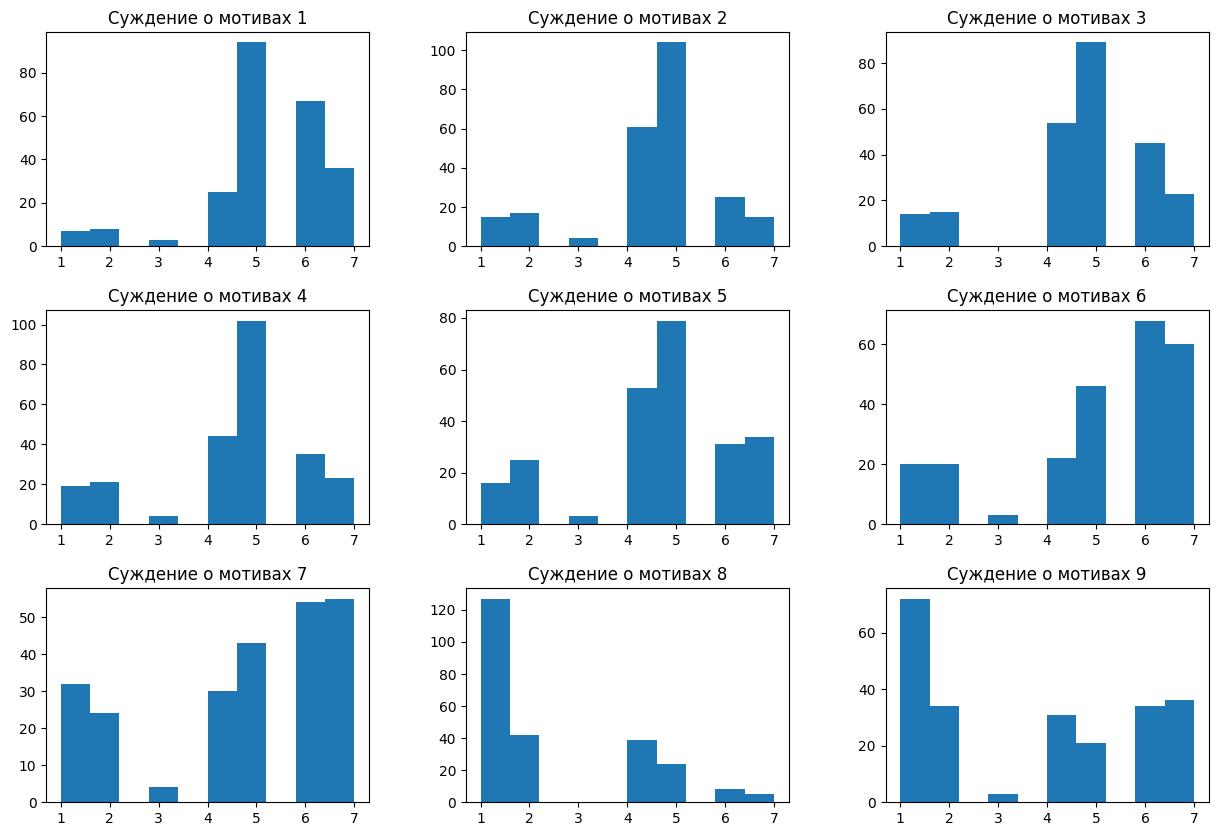

In [ ]:
d[sp].hist(figsize=(15, 10), grid=False, )

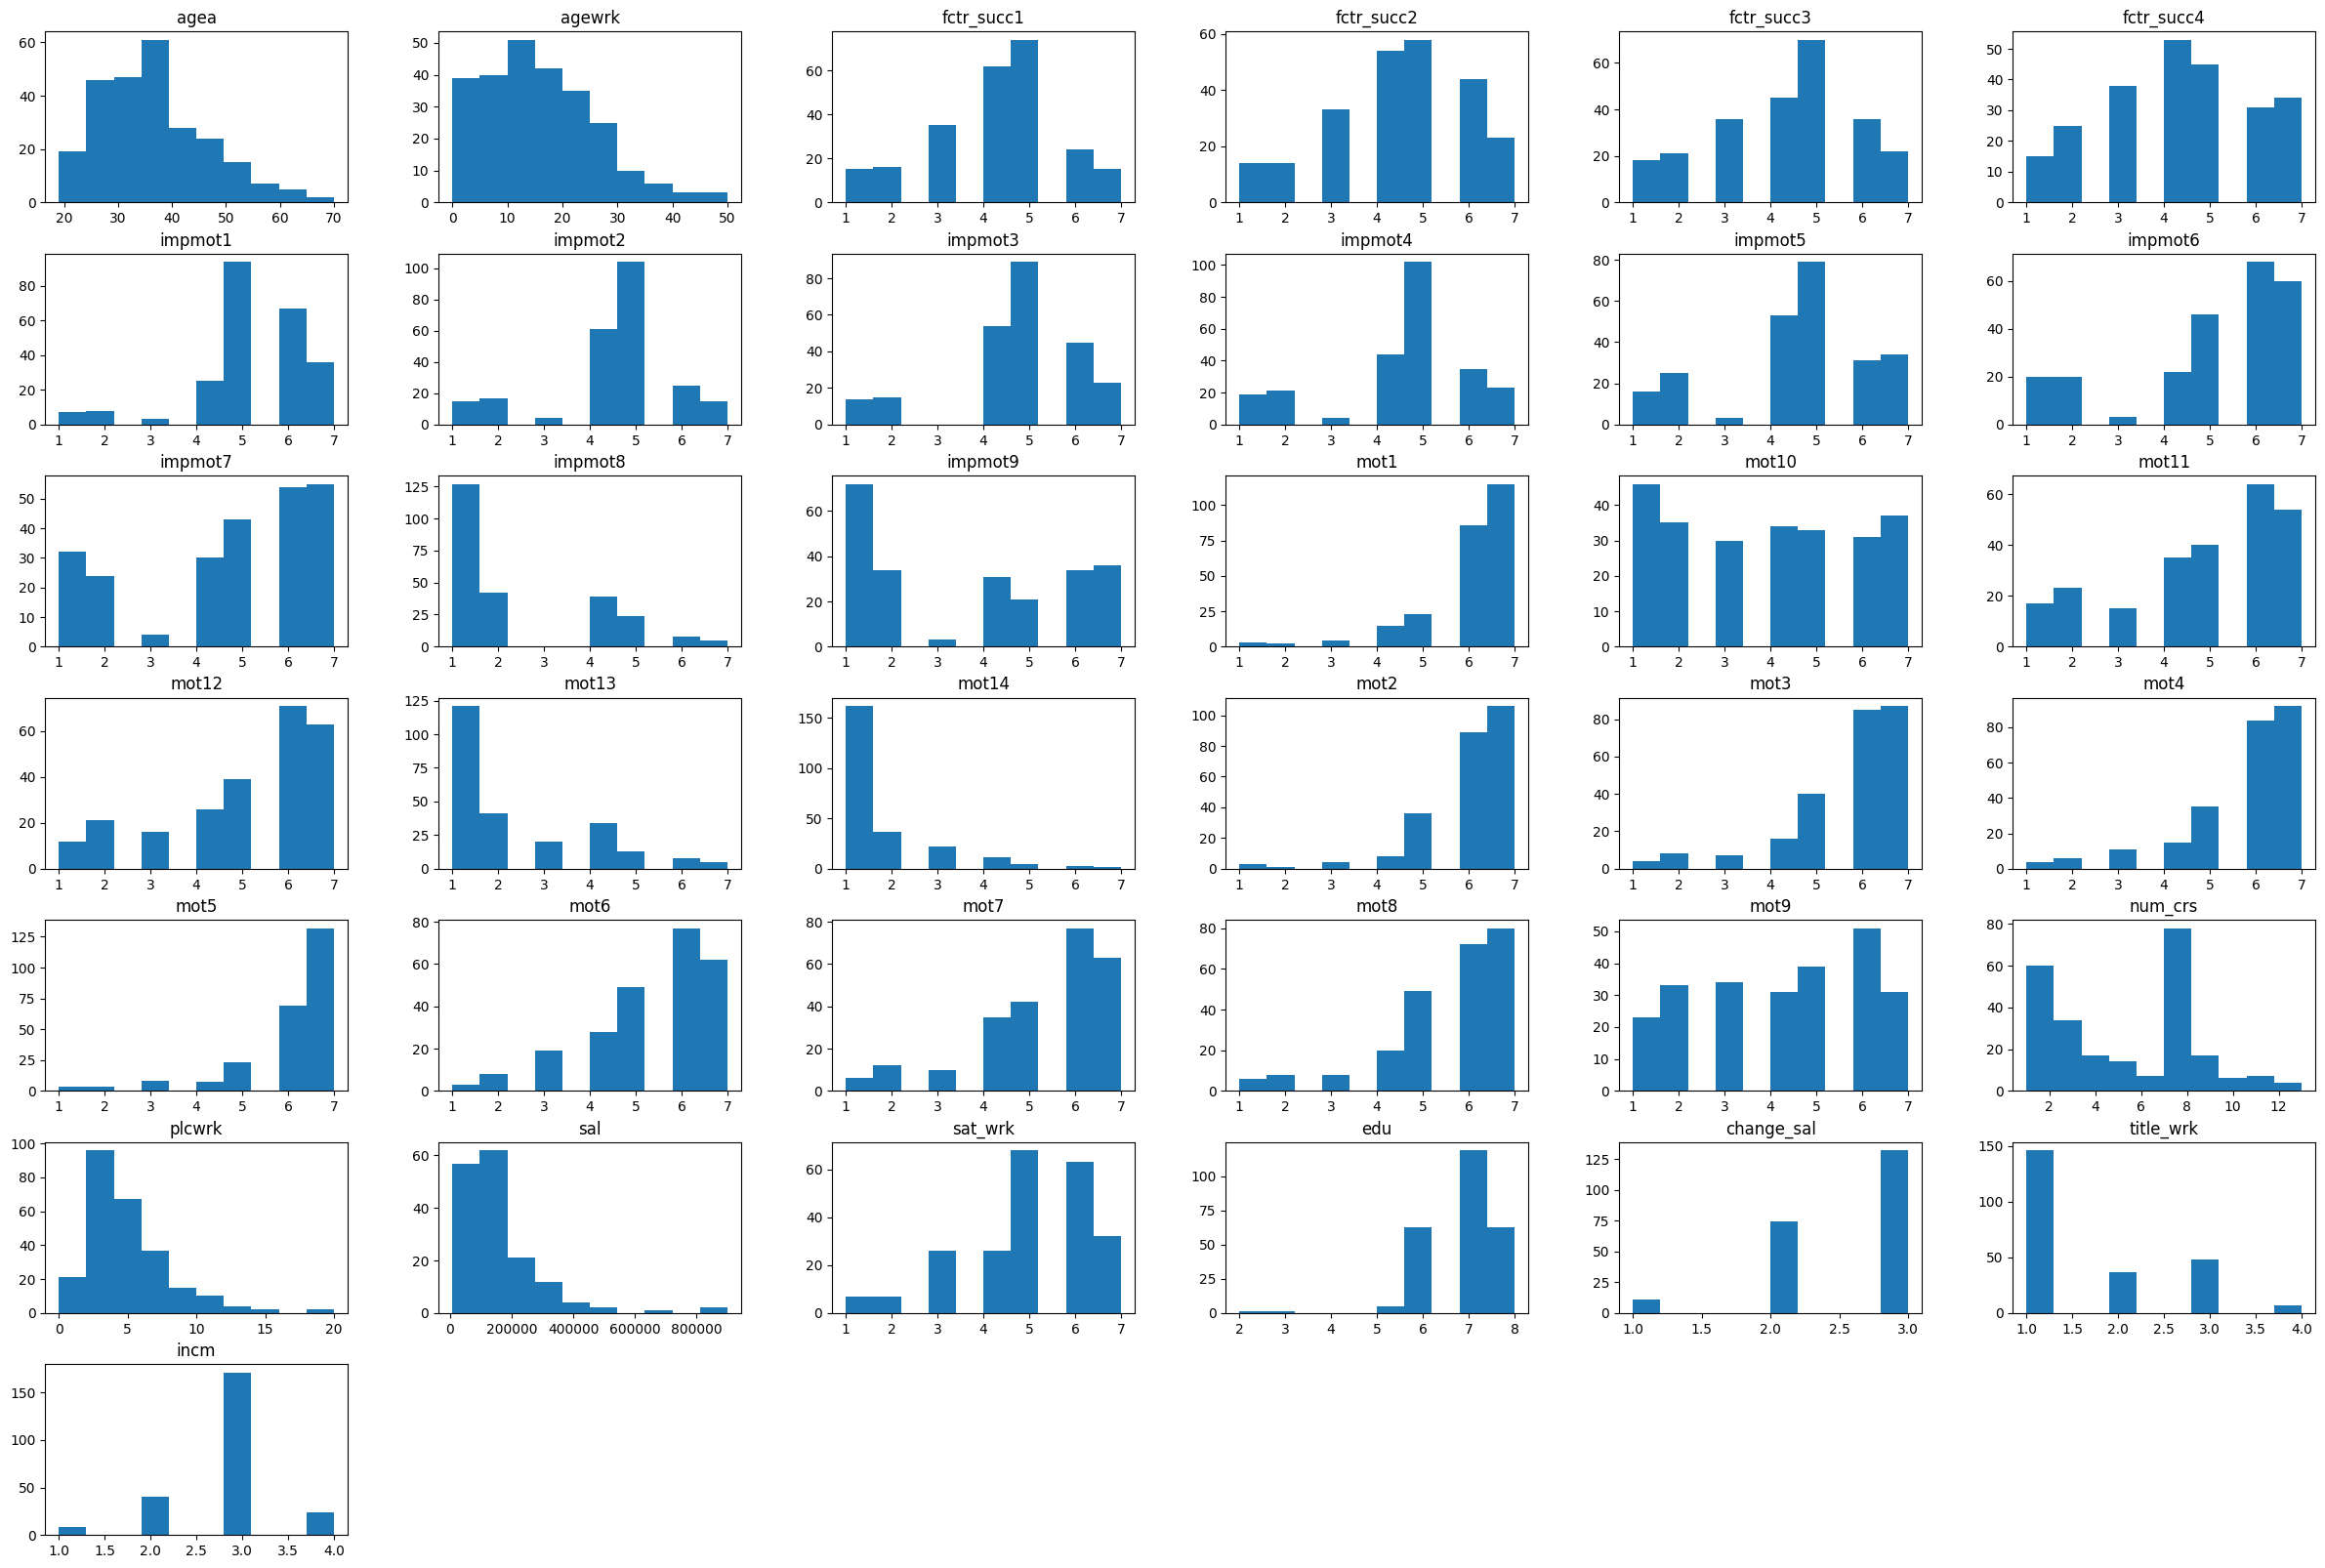

In [ ]:
data[int_ord].hist(figsize=(30, 20), grid=False, )
plt.grid(False)

In [ ]:
data[int_cols].rename(columns=ss).hist(figsize=(30, 20), grid=False, )
plt.grid(False)


NameError: name 'ss' is not defined

In [ ]:
ss = {}

for i in ord_cols:
  ss[i] = sl[i]

In [ ]:
# data[ord_cols].rename(columns=ss).hist(figsize=(15, 10), grid=False)

In [ ]:
m = ['mot1', 'mot2', 'mot3', 'mot4', 'mot5', 'mot6', 'mot7',
       'mot8']


f = ['fctr_succ1', 'fctr_succ2', 'fctr_succ3',
       'fctr_succ4']

im = ['impmot1', 'impmot2', 'impmot3', 'impmot4', 'impmot5',
       'impmot6', 'impmot7', 'impmot8', 'impmot9']

In [ ]:
for i in cat_cols:
  k = data[i].value_counts().sort_index()
  k = k.rename(sl[i])
  k.to_excel('pivot_table_'+i+'.xlsx')



In [ ]:
for i in ord_cols:
  k = data[i].value_counts().sort_index()
  k = k.rename(sl[i])
  k.to_excel('pivot_table_'+i+'.xlsx')


In [ ]:
ord_cols

['edu', 'change_sal', 'title_wrk', 'incm']